<a href="https://colab.research.google.com/github/Diego-Cano-bit/CIMAT-Monterrey/blob/main/LDA_%26_QDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from scipy import linalg
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import colors
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
# por esta ocasion, no pongo las graficas inline, para poder mostrarlas en un␣slide aparte...
#%matplotlib inline
plt.ioff() # pongo Interactive Mode Off
plt.style.use('seaborn')

<ipython-input-1-a98d7f6df3eb>:11: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


In [ ]:
def dataset_fixed_cov():
  '''Generate 2 Gaussians samples with the same covariance matrix'''
  n, dim = 1000, 2
  np.random.seed(0)
  C = np.array([[0., -0.23], [0.83, .23]])
  X = np.r_[np.dot(np.random.randn(n, dim), C),
  np.dot(np.random.randn(n, dim), C) + np.array([1, 1])]
  y = np.hstack((np.zeros(n), np.ones(n)))
  return X, y
def dataset_cov():
  '''Generate 2 Gaussians samples with different covariance matrices'''
  n, dim = 300, 2
  np.random.seed(0)
  C = np.array([[0., -1.], [2.5, .7]]) * 2.
  X = np.r_[np.dot(np.random.randn(n, dim), C),
  np.dot(np.random.randn(n, dim), C.T) + np.array([1, 4])]
  y = np.hstack((np.zeros(n), np.ones(n)))
  return X, y


In [ ]:
def plot_data(lda, X, y, y_pred, fig_index):
  splot = plt.subplot(2, 2, fig_index)
  if fig_index == 1:
      plt.title('Linear Discriminant Analysis')
      plt.ylabel('Data with\n fixed covariance')
  elif fig_index == 2:
    plt.title('Quadratic Discriminant Analysis')
  elif fig_index == 3:
    plt.ylabel('Data with\n varying covariances')

  tp = (y == y_pred) # True Positive
  tp0, tp1 = tp[y == 0], tp[y == 1]
  X0, X1 = X[y == 0], X[y == 1]
  X0_tp, X0_fp = X0[tp0], X0[~tp0]
  X1_tp, X1_fp = X1[tp1], X1[~tp1]
  # class 0: dots
  plt.scatter(X0_tp[:, 0], X0_tp[:, 1], marker='.', color='red')
  plt.scatter(X0_fp[:, 0], X0_fp[:, 1], marker='x',
  s=20, color='#990000') # dark red
  # class 1: dots
  plt.scatter(X1_tp[:, 0], X1_tp[:, 1], marker='.', color='blue')
  plt.scatter(X1_fp[:, 0], X1_fp[:, 1], marker='x',
  s=20, color='#000099') # dark blue
  # class 0 and 1 : areas
  nx, ny = 200, 100
  x_min, x_max = plt.xlim()
  y_min, y_max = plt.ylim()
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, nx),
  np.linspace(y_min, y_max, ny))
  Z = lda.predict_proba(np.c_[xx.ravel(), yy.ravel()])
  Z = Z[:, 1].reshape(xx.shape)
  plt.pcolormesh(xx, yy, Z, cmap='red_blue_classes', norm=colors.Normalize(0., 1.), zorder=0, shading='auto')
  plt.contour(xx, yy, Z, [0.5], linewidths=2., colors='white')
  # means
  plt.plot(lda.means_[0][0], lda.means_[0][1],
  '*', color='yellow', markersize=15, markeredgecolor='grey')
  plt.plot(lda.means_[1][0], lda.means_[1][1],
  '*', color='yellow', markersize=15, markeredgecolor='grey')
  return splot



In [ ]:
def plot_ellipse(splot, mean, cov, color):
  v, w = linalg.eigh(cov)
  u = w[0] / linalg.norm(w[0])
  angle = np.arctan(u[1] / u[0])
  angle = 180 * angle / np.pi # convert to degrees
  # filled Gaussian at 2 standard deviation
  ell = mpl.patches.Ellipse(mean, 2 * v[0] ** 0.5, 2 * v[1] ** 0.5,
  180 + angle, facecolor=color,
  edgecolor='black', linewidth=2)
  ell.set_clip_box(splot.bbox)
  ell.set_alpha(0.2)
  splot.add_artist(ell)
  splot.set_xticks(())
  splot.set_yticks(())

def plot_lda_cov(lda, splot):
  plot_ellipse(splot, lda.means_[0], lda.covariance_, 'red')
  plot_ellipse(splot, lda.means_[1], lda.covariance_, 'blue')
def plot_qda_cov(qda, splot):
  plot_ellipse(splot, qda.means_[0], qda.covariance_[0], 'red')
  plot_ellipse(splot, qda.means_[1], qda.covariance_[1], 'blue')


In [ ]:
plt.figure(figsize=(10, 8), facecolor='white')
plt.suptitle('Linear Discriminant Analysis vs Quadratic Discriminant Analysis', y=0.98, fontsize=15)

for i, (X, y) in enumerate([dataset_fixed_cov(), dataset_cov()]):
    # Linear Discriminant Analysis
    lda = LinearDiscriminantAnalysis(solver="svd", store_covariance=True)
    y_pred = lda.fit(X, y).predict(X)
    splot = plot_data(lda, X, y, y_pred, fig_index=2 * i + 1)
    plot_lda_cov(lda, splot)
    plt.axis('tight')
    # Quadratic Discriminant Analysis
    qda = QuadraticDiscriminantAnalysis(store_covariance=True)
    y_pred = qda.fit(X, y).predict(X)
    splot = plot_data(qda, X, y, y_pred, fig_index=2 * i + 2)
    plot_qda_cov(qda, splot)
    plt.axis('tight')

plt.tight_layout()
plt.subplots_adjust(top=0.92)

<ipython-input-29-914271467fd2>:7: MatplotlibDeprecationWarning: Passing the angle parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  ell = mpl.patches.Ellipse(mean, 2 * v[0] ** 0.5, 2 * v[1] ** 0.5,
<ipython-input-29-914271467fd2>:7: MatplotlibDeprecationWarning: Passing the angle parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  ell = mpl.patches.Ellipse(mean, 2 * v[0] ** 0.5, 2 * v[1] ** 0.5,
<ipython-input-29-914271467fd2>:7: MatplotlibDeprecationWarning: Passing the angle parameter of __init__() positionally is deprecated since Matplotlib 3.6; the parameter will become keyword-only two minor releases later.
  ell = mpl.patches.Ellipse(mean, 2 * v[0] ** 0.5, 2 * v[1] ** 0.5,
<ipython-input-29-914271467fd2>:7: MatplotlibDeprecationWarning: Passing the angle parameter of __init__() positionally is deprecated

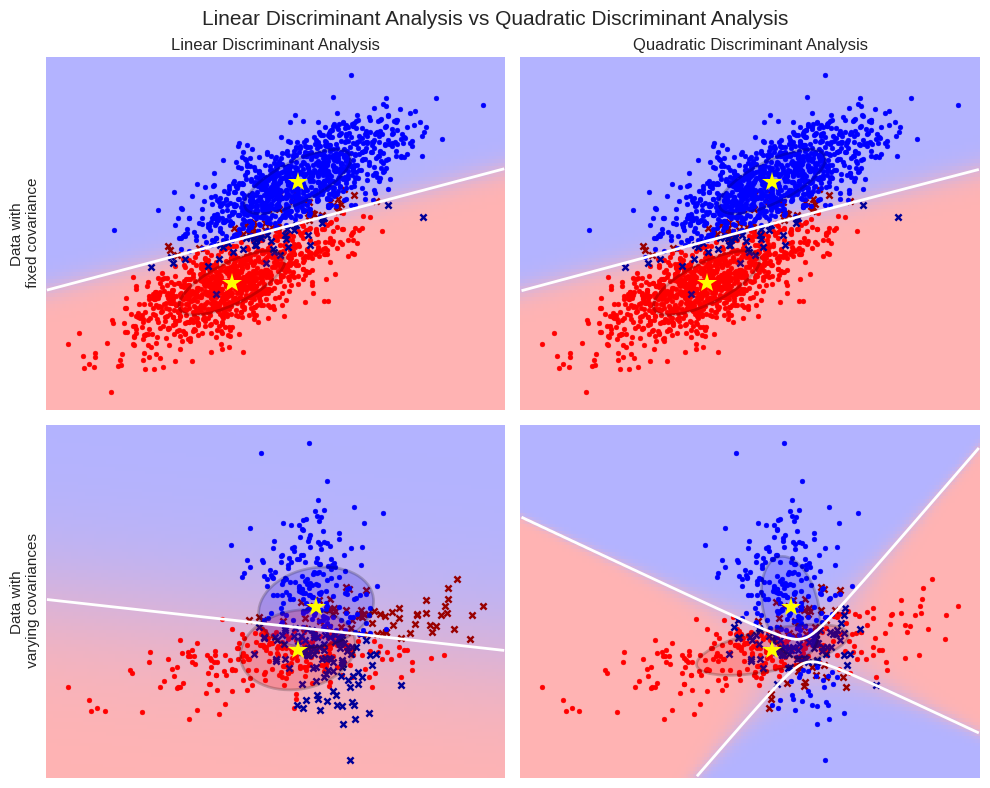

In [ ]:
plt.show()